## Практическая работа 4 - Себежко А.А. П50-1-22

Цель работы: Построить 5 диаграмм (графиков) следующего вида: линейный график, гистограмма, столбчатый график, круговая диаграмма, дисперсионный график.

Ход работы:

Импортируем библиотеки `pandas` и `numpy`, а также библиотеку для построение графиков `matplotlib`.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Импортируем датасет с данными из приюта и выведем информацию по нему.

In [45]:
df = pd.read_csv("pet_adoption_data.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2007 entries, 0 to 2006
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PetID               2007 non-null   int64  
 1   PetType             2007 non-null   object 
 2   Breed               2007 non-null   object 
 3   AgeMonths           2007 non-null   int64  
 4   Color               2007 non-null   object 
 5   Size                2007 non-null   object 
 6   WeightKg            2007 non-null   float64
 7   Vaccinated          2007 non-null   int64  
 8   HealthCondition     2007 non-null   int64  
 9   TimeInShelterDays   2007 non-null   int64  
 10  AdoptionFee         2007 non-null   int64  
 11  PreviousOwner       2007 non-null   int64  
 12  AdoptionLikelihood  2007 non-null   int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 204.0+ KB


Удалим все пустые значения, а также повторяющиеся записи.

In [46]:
df.dropna()
df.drop_duplicates()

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
0,500,Bird,Parakeet,131,Orange,Large,5.039768,1,0,27,140,0,0
1,501,Rabbit,Rabbit,73,White,Large,16.086727,0,0,8,235,0,0
2,502,Dog,Golden Retriever,136,Orange,Medium,2.076286,0,0,85,385,0,0
3,503,Bird,Parakeet,97,White,Small,3.339423,0,0,61,217,1,0
4,504,Rabbit,Rabbit,123,Gray,Large,20.498100,0,0,28,14,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2002,2502,Dog,Poodle,72,Orange,Small,27.039045,1,0,66,26,1,1
2003,2503,Rabbit,Rabbit,124,Brown,Small,4.726954,1,1,59,150,0,0
2004,2504,Rabbit,Rabbit,113,Orange,Small,1.758592,1,0,68,302,0,0
2005,2505,Dog,Labrador,12,Gray,Large,20.961592,1,0,59,478,0,0


Построим первый график - линейный.

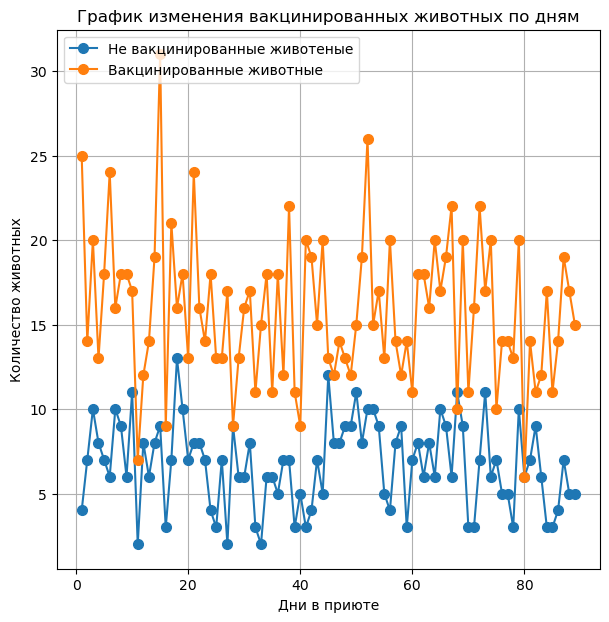

In [133]:
x = sorted(df['TimeInShelterDays'].unique())
y = df[df['Vaccinated'] == 0].groupby(
    'TimeInShelterDays').count().reset_index()['Vaccinated'].to_numpy()
y2 = df[df['Vaccinated'] == 1].groupby(
    'TimeInShelterDays').count().reset_index()['Vaccinated'].to_numpy()

figure = plt.figure(figsize=(7, 7))

plt.title('График изменения вакцинированных животных по дням')
plt.xlabel('Дни в приюте')
plt.ylabel('Количество животных')

plt.plot(x, y, label='Не вакцинированные животеные', marker='o', markersize=7)
plt.plot(x, y2, label='Вакцинированные животные', marker='o', markersize=7)


plt.legend(loc='upper left')
plt.grid()
plt.show()

По результату построения линейного графика было выяснено, что нет определенного тренда по вакцинировании животных по количеству дней проведенных в приюте.

Построим второй график - столбчатый график.

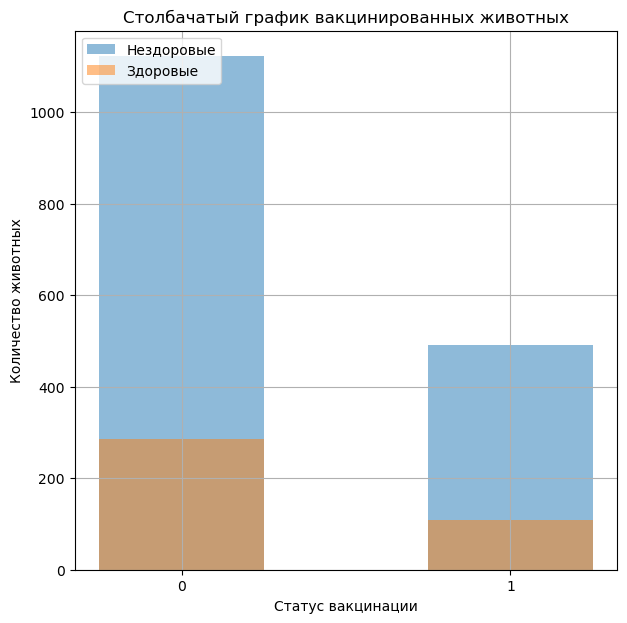

In [117]:
x = df['Vaccinated'].unique()
y = df[df['HealthCondition'] == 0].groupby(
    'Vaccinated').count().reset_index()['HealthCondition'].to_numpy()
y2 = df[df['HealthCondition'] == 1].groupby(
    'Vaccinated').count().reset_index()['HealthCondition'].to_numpy()

plt.figure(figsize=(7, 7))
plt.title('Столбачатый график вакцинированных животных')
plt.xlabel('Статус вакцинации')
plt.ylabel('Количество животных')
plt.bar(x, height=y, label='Нездоровые', alpha=0.5, width=0.5)
plt.bar(x, height=y2, label='Здоровые', alpha=0.5, width=0.5)
plt.xticks(ticks=[0,1])

plt.legend(loc='upper left')
plt.grid()
plt.show()

По результату построения столбчатого графика по соотношению вакцинированных не вакцинированных животных и состояния их здоровья в приюте, можно сделать вывод, что диаграмма показывает, что больше животных нездоровы, по сравнению со здоровыми, и что среди вакцинированных животных меньше нездоровых, чем среди не вакцинированных.

Построим третий график - гистограмма.

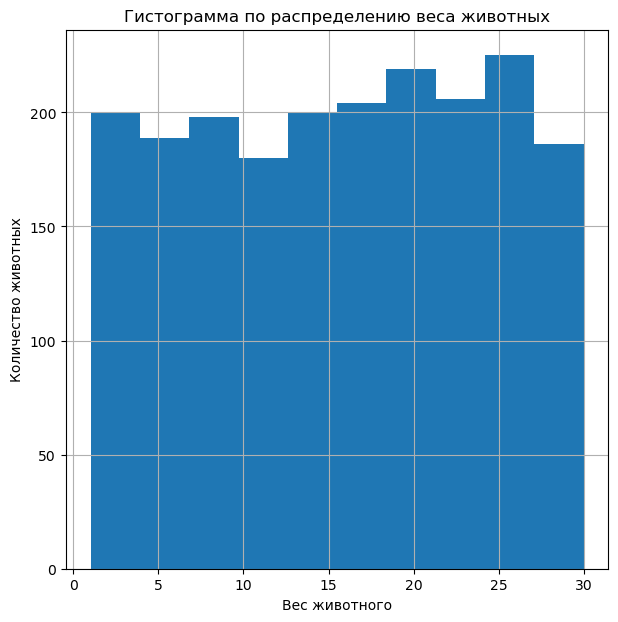

In [134]:
plt.figure(figsize=(7, 7))
plt.title('Гистограмма по распределению веса животных')
plt.xlabel('Вес животного')
plt.ylabel('Количество животных')

plt.hist(df['WeightKg'])
plt.grid()
plt.show()

По результату построения гистограммы по распределению веса животных в приюте,
можно сделать вывод, что в приюте усредненное значение веса животных. Но преобладающий вес животных от 24 до 27 кг. Самая меньшая группа имеет вес от 9 до 13 кг.

Построим четвертый график - круговой.

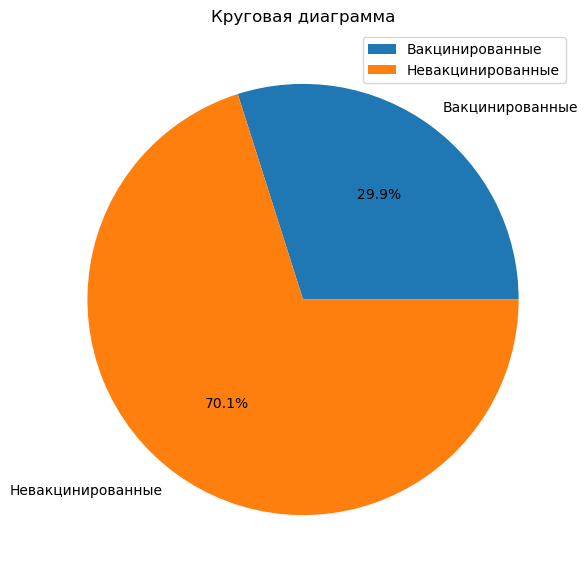

In [136]:
count_vaccinated = df.groupby('Vaccinated').count().reset_index()[
    'PetID'].to_numpy()

plt.figure(figsize=(7, 7))
plt.title('Круговая диаграмма')
plt.pie(count_vaccinated, labels=[
        'Вакцинированные', 'Невакцинированные'], autopct='%1.1f%%')
plt.legend()
plt.show()

По результату построения круговой диаграммы по распределению вакцинированных животных в приюте, можно сделать вывод, что в приюте большую часть животных привили, а следовательно шанс, что их заберут больше.

Построим последний график - дисперсионный.

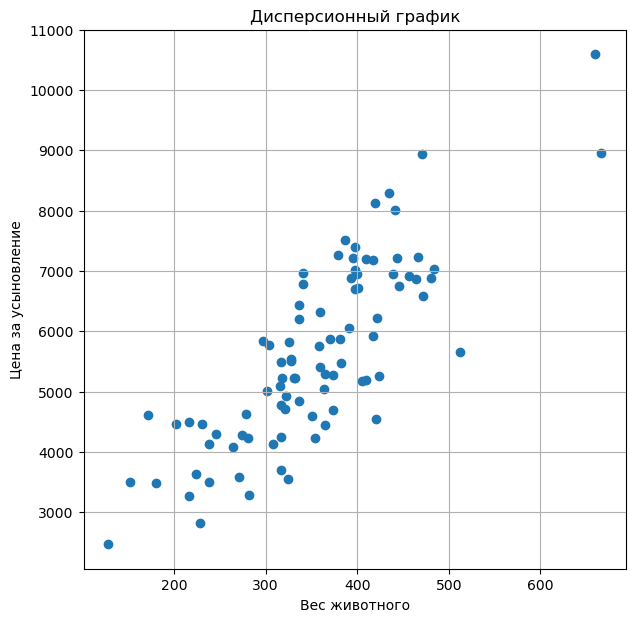

In [92]:
x = df.groupby('TimeInShelterDays').sum().reset_index()['WeightKg'].to_numpy()

y = df.groupby('TimeInShelterDays').sum().reset_index()[
    'AdoptionFee'].to_numpy()

plt.figure(figsize=(7,7))
plt.title('Дисперсионный график')
plt.xlabel('Вес животного')
plt.ylabel('Цена за усыновление')
plt.scatter(x, y)
plt.grid()
plt.show()

По результату построения дисперсионного графика по зависимости веса животного к цене его усыновления. Исходя из графика можно сделать вывод, чем больше животное весит тем оно дороже. Скорее всего это связано с породой животного, так как породистые кошки или собаки весят очень много.

Вывод: Было построено 5 диаграмм (графиков) следующего вида: линейный график, гистограмма, столбчатый график, круговая диаграмма, дисперсионный график.